In [1]:
using QuantumClifford
using Statistics
using PyPlot
using Profile

include("../src/binary_linalg.jl")

binary_charge_conserving_symplectic_mat

In [2]:
all_up(L) = one(MixedDestabilizer, L)
# rand_2cliff() = random_clifford(2; phases=true)

function rand_2cliff()
    xz = binary_random_symplectic_matrix(2)
    x = zeros(Bool, 4, 2)
    z = zeros(Bool, 4, 2)
    
    
    x[1:2, :] = xz[1:2:4, 1:2:4]
    x[3:4, :] = xz[2:2:4, 1:2:4]
    
    z[1:2, :] = xz[1:2:4, 2:2:4]
    z[3:4, :] = xz[2:2:4, 2:2:4]
    
    
    s = fill(0x0, 4)
    for k in 1:4
        s[k] = UInt8(2*rand(Bool))
    end
    
    tmp = tab(Stabilizer(s, x, z))
    q = CliffordOperator(tmp)
    return q
end

function measure_Z!(state, posi)
    newstate, result = projectZrand!(state, posi)
    
    if result == 0x0
        return 1
    else
        return -1
    end
end

measure_Z! (generic function with 1 method)

In [3]:
function get_gates(L, T)
    @assert iseven(L) && iseven(T)
    
    tmp = [rand_2cliff() for _ in 1:div(L,2)*T]
    gates_forward = reshape(tmp, T, div(L,2))
    gates_backward = [inv(g) for g in gates_forward]
    
    return gates_forward, gates_backward
end

function get_meas_locs(L, T, p)
    tmp = [(rand()<p ? true : false) for _ in 1:L*T]
    return reshape(tmp, T, L)
end

function two_way_run(state, gates_forward, gates_backward, locs)
    T, L = size(locs)
    outcomes = zeros(Int, T, L)
    
    for t in 1:T
        ini = (iseven(t) ? 0 : 1)
        
        for i in 1:div(L,2)
            a = 2i - ini
            b = (a==L) ? 1 : a+1
            
            if locs[t, a]
                outcomes[t, a] = measure_Z!(state, a)
            end
            if locs[t, b]
                outcomes[t, b] = measure_Z!(state, b)
            end
            
            gate = gates_forward[t, i]
            apply!(state, gate, [a, b])
        end
    end
    
    for t in T:-1:1
        ini = (iseven(t) ? 0 : 1)
        for i in 1:div(L,2)
            a = 2i - ini
            b = (a==L) ? 1 : a+1
            
            gate = gates_backward[t, i]
            apply!(state, gate, [a, b])
            
            if locs[t, a]
                outcomes[t, a] *= measure_Z!(state, a)
            end
            if locs[t, b]
                outcomes[t, b] *= measure_Z!(state, b)
            end
            
        end
    end
    
    return outcomes
end


function one_sample(L, T, p)
    gf, gb = get_gates(L, T)
    locs = get_meas_locs(L, T, p)
    state = all_up(L)

    outcomes = two_way_run(state, gf, gb, locs)
    return outcomes
end

one_sample (generic function with 1 method)

In [4]:
L = 32
T = 16
p = 0.1

n_avg = 100000

result = mean([one_sample(L,T,p) for _ in 1:n_avg])


16×32 Matrix{Float64}:
 -0.0002    0.00019   0.00192   0.00064  …  -0.00044   0.0009   -0.00093
  0.00239  -0.00069  -0.00122   0.00107      0.00145  -0.00053  -0.00049
  0.00144   0.00053   0.00072  -5.0e-5       0.00071  -0.00014   4.0e-5
  0.00181   0.00172   0.00243   0.00269      0.00199   0.00087  -0.00063
  0.00266   0.00309   0.00024   0.00151      0.00178  -0.00052   0.00096
  0.00385   0.00352   0.00451   0.00212  …   0.00323   0.00338   0.00302
  0.00448   0.00542   0.00604   0.0068       0.00697   0.00409   0.00565
  0.00673   0.00902   0.00897   0.00924      0.01033   0.01024   0.0092
  0.01366   0.01467   0.01477   0.01499      0.01476   0.01386   0.0148
  0.02485   0.02356   0.02411   0.02168      0.02071   0.02024   0.02175
  0.03249   0.03232   0.03073   0.03493  …   0.03459   0.03182   0.03262
  0.04674   0.04629   0.04547   0.04528      0.04507   0.04518   0.04707
  0.0586    0.06133   0.061     0.05951      0.05949   0.05989   0.06022
  0.0752    0.07592   0.07566  

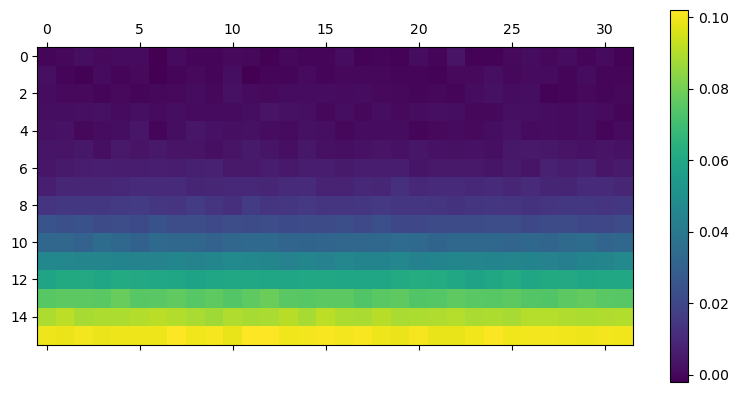

PyObject <matplotlib.colorbar.Colorbar object at 0x000002A028B138E0>

In [5]:
matshow(result)
colorbar()

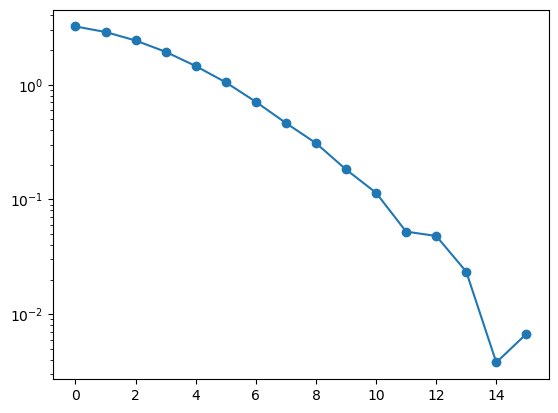

In [10]:
plot(sum(result; dims=2)[end:-1:1], "-o")
yscale("log")
# xscale("log")